In [2]:
!pip install --quiet pmdarima

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import pmdarima as pm
from pmdarima import auto_arima
from pmdarima.model_selection import RollingForecastCV
from pmdarima.model_selection import cross_val_score
from pmdarima.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from scipy.stats import norm

In [3]:
# Read dataframe
df = pd.read_csv('../data/validaciones12m.csv', index_col='Fecha', parse_dates=['Fecha'])
df.head(3)

,(10000) Portal 20 de Julio,(10001) Country Sur,(10002) Av. Primero de Mayo,(10003) Ciudad Jardín,(10004) Policarpa,(10010) San Bernardo,(10005) Bicentenario,(10006) SAN VICTORINO - NEOS CENTRO,(10007) Las Nieves,(10008) San Diego,Feriado,Dia_semana,Operativo
Fecha,,,,,,,,,,,,,
2025-04-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-01 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This dataframe has 15 minutes intervals covering 24 hours of data for each day, but there are about 4 hours a day with NaN values due to the non-operational window of Transmilenio. So, I'm going to simply group data by day in order to avoid issues with the ARIMA-SARIMA models.

In [4]:
# Group by daily frequency
df_a = df.groupby(pd.Grouper(freq='D'))[df.columns[0:10]].sum()
print(df_a.shape)
df_a.head()

(365, 10)


,(10000) Portal 20 de Julio,(10001) Country Sur,(10002) Av. Primero de Mayo,(10003) Ciudad Jardín,(10004) Policarpa,(10010) San Bernardo,(10005) Bicentenario,(10006) SAN VICTORINO - NEOS CENTRO,(10007) Las Nieves,(10008) San Diego
Fecha,,,,,,,,,,
2025-04-01,32307.0,12687.0,18455.0,2983.0,3309.0,6629.0,4813.0,14104.0,11564.0,5194.0
2025-04-02,31905.0,13008.0,18526.0,3026.0,3490.0,6563.0,5042.0,17041.0,12707.0,5908.0
2025-04-03,30577.0,11842.0,17342.0,2944.0,3180.0,6337.0,4717.0,13401.0,11401.0,5183.0
2025-04-04,32689.0,12702.0,18613.0,3091.0,3240.0,6413.0,4756.0,15307.0,12455.0,5627.0
2025-04-05,24869.0,9590.0,13687.0,2345.0,3096.0,4249.0,3163.0,15860.0,10332.0,3955.0


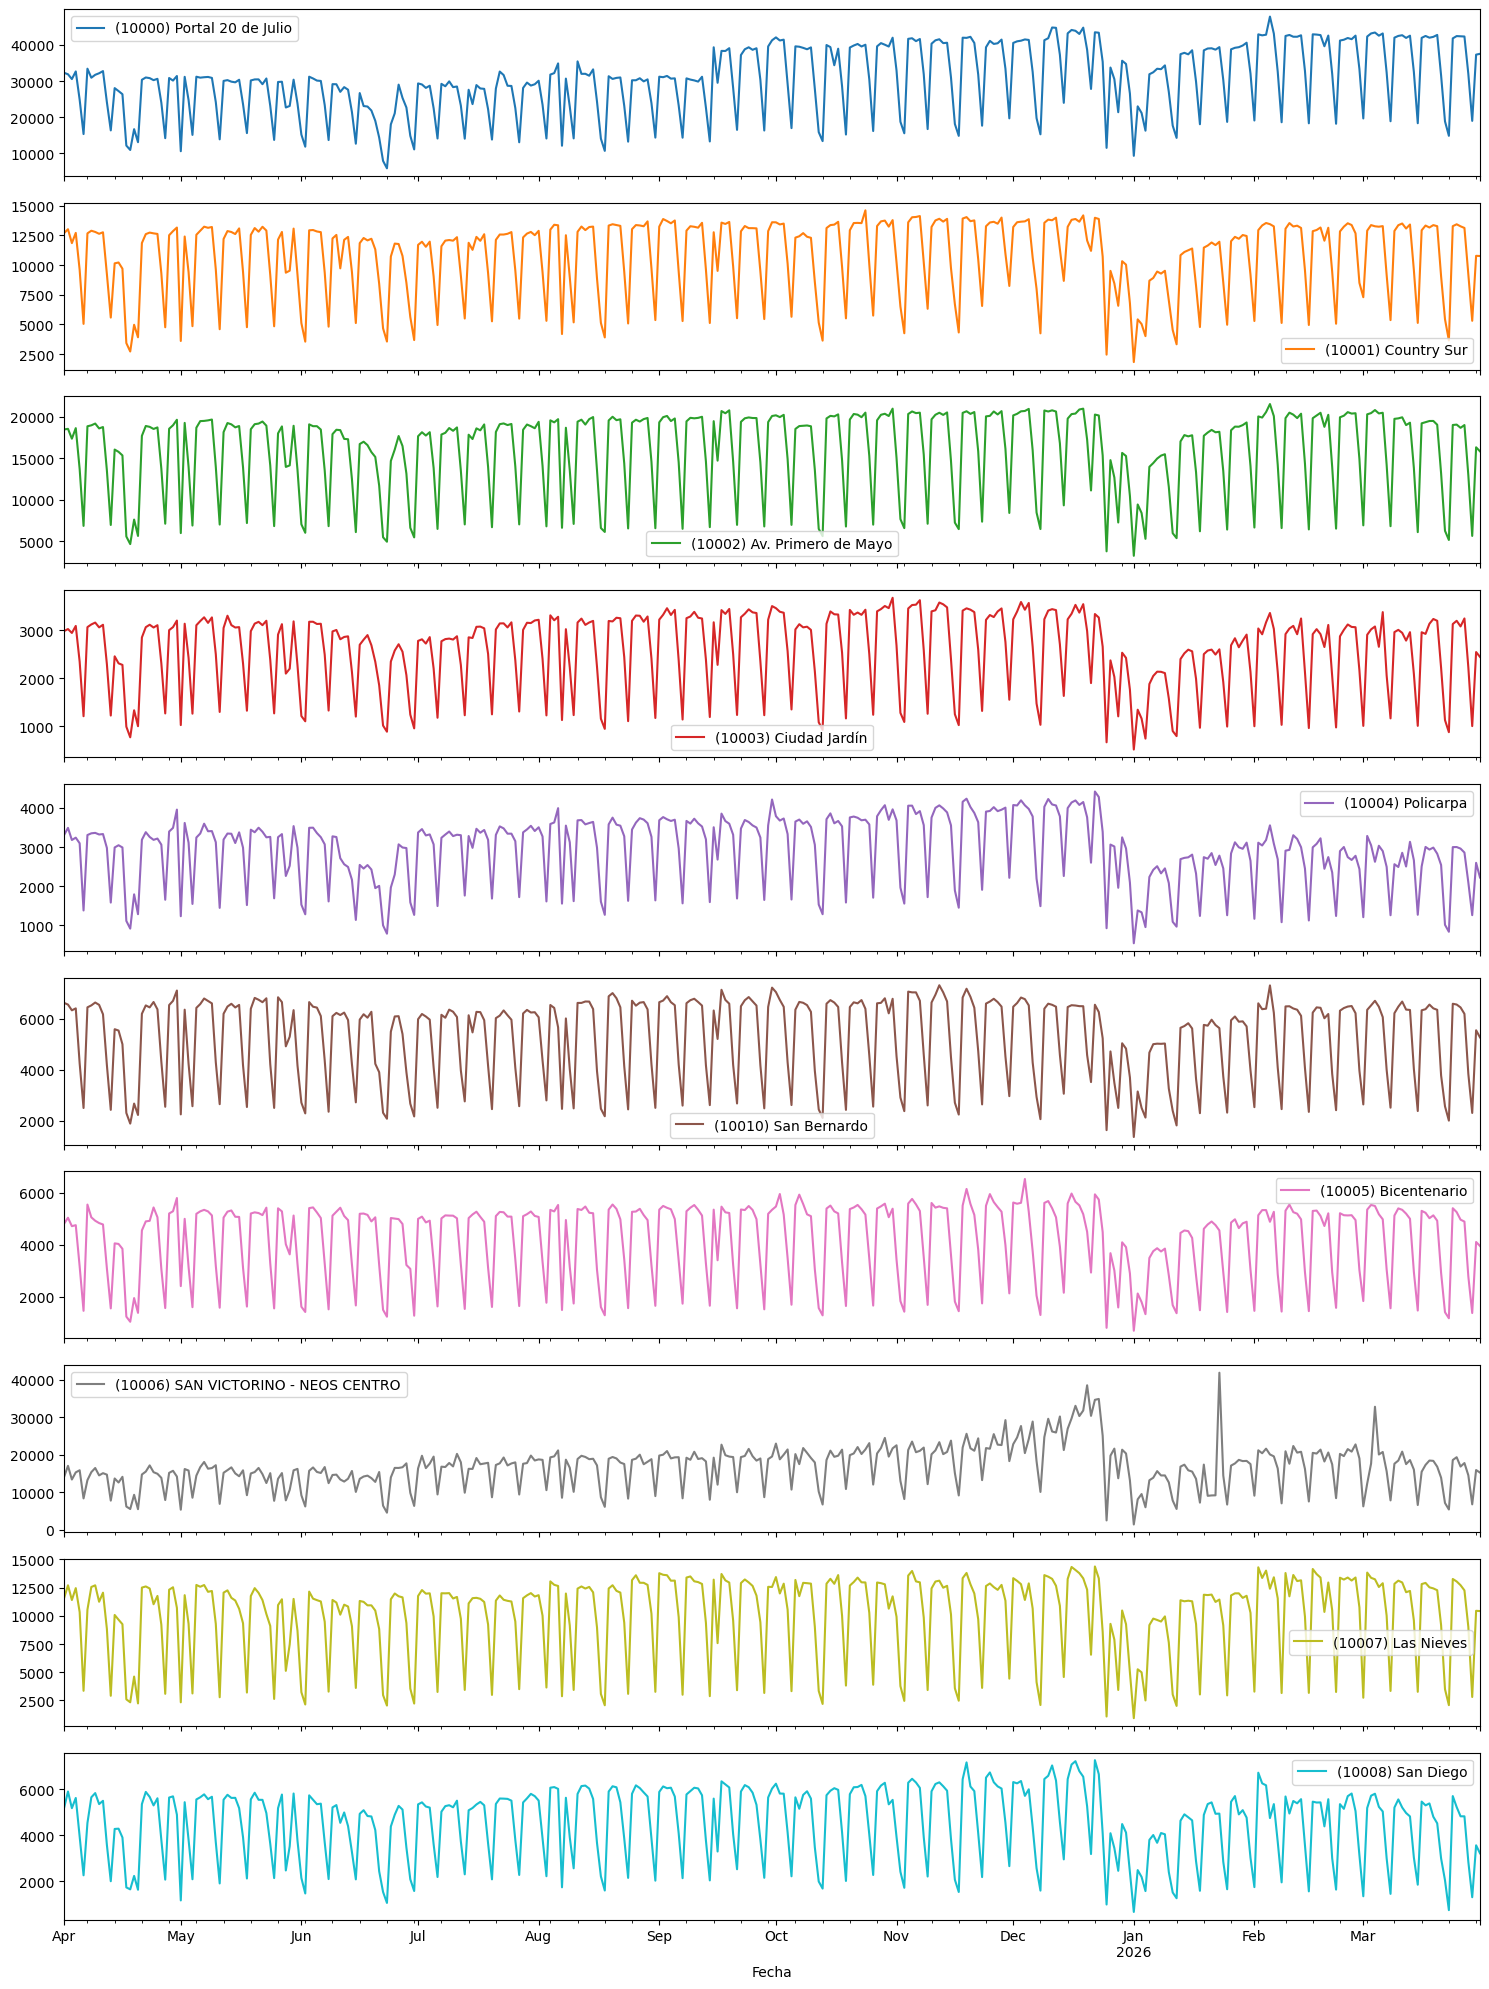

In [5]:
# Entries (validations) per station in the trunk line Carrera 10
df_a.iloc[:, 0:10].plot(subplots=True, figsize=(15, 20), layout=(10, 1))
plt.tight_layout()
plt.show()

In [6]:
# Define function for the auto_arima model
def training_auto_arima(df, n_splits): # df must be the training set, defined when separating the holdout set
    results = []
    for col in df.columns:
        # Train-test split for time series cross validation
        tscv = TimeSeriesSplit(n_splits=n_splits)
        split_num = 0
        for train_index, test_index in tscv.split(df[col]):
            split_num += 1
            train, test = df[col].iloc[train_index], df[col].iloc[test_index]
            arima_model = auto_arima(train, seasonal=False)
            order = getattr(arima_model, 'order', None) or getattr(arima_model, 'order_', None)
            results.append({
                'column': col,
                'split': split_num,
                'train_start': train.index[0],
                'train_end': train.index[-1],
                'test_start': test.index[0],
                'test_end': test.index[-1],
                'size_train': len(train),
                'size_test': len(test),
                'order': order
            })
    results = pd.DataFrame(results)

    return results


In [7]:
# Holdout set is 15% of the whole dataset
train_set, holdout_set = train_test_split(df_a, train_size=0.85)
print(train_set.shape)
print(holdout_set.shape)

(310, 10)
(55, 10)


In [10]:
# If m = 1 (non-seasonal, default), seasonal is set to false
results = training_auto_arima(train_set, n_splits=10)
results

,column,split,train_start,train_end,test_start,test_end,size_train,size_test,order
0,(10000) Portal 20 de Julio,1,2025-04-01,2025-04-30,2025-05-01,2025-05-28,30,28,"(1, 0, 0)"
1,(10000) Portal 20 de Julio,2,2025-04-01,2025-05-28,2025-05-29,2025-06-25,58,28,"(0, 0, 1)"
2,(10000) Portal 20 de Julio,3,2025-04-01,2025-06-25,2025-06-26,2025-07-23,86,28,"(0, 0, 1)"
3,(10000) Portal 20 de Julio,4,2025-04-01,2025-07-23,2025-07-24,2025-08-20,114,28,"(0, 0, 1)"
4,(10000) Portal 20 de Julio,5,2025-04-01,2025-08-20,2025-08-21,2025-09-17,142,28,"(0, 0, 1)"
...,...,...,...,...,...,...,...,...,...
95,(10008) San Diego,6,2025-04-01,2025-09-17,2025-09-18,2025-10-15,170,28,"(5, 0, 0)"
96,(10008) San Diego,7,2025-04-01,2025-10-15,2025-10-16,2025-11-12,198,28,"(4, 1, 5)"
97,(10008) San Diego,8,2025-04-01,2025-11-12,2025-11-13,2025-12-10,226,28,"(5, 1, 3)"
98,(10008) San Diego,9,2025-04-01,2025-12-10,2025-12-11,2026-01-07,254,28,"(0, 1, 0)"


In [11]:
orders = results.groupby('column')['order'].unique().to_frame()
orders

,order
column,
(10000) Portal 20 de Julio,"[(1, 0, 0), (0, 0, 1), (5, 0, 2), (0, 1, 2), (..."
(10001) Country Sur,"[(1, 0, 0), (0, 0, 1), (2, 0, 0), (5, 0, 0), (..."
(10002) Av. Primero de Mayo,"[(1, 0, 0), (0, 0, 1), (5, 0, 0), (5, 0, 5), (..."
(10003) Ciudad Jardín,"[(1, 0, 0), (0, 0, 1), (2, 0, 0), (5, 0, 0), (..."
(10004) Policarpa,"[(1, 0, 0), (0, 0, 0), (3, 0, 3), (2, 1, 3), (..."
(10005) Bicentenario,"[(0, 0, 1), (2, 0, 0), (5, 0, 0), (5, 1, 2)]"
(10006) SAN VICTORINO - NEOS CENTRO,"[(1, 0, 0), (0, 0, 0), (0, 0, 1), (2, 1, 3), (..."
(10007) Las Nieves,"[(1, 0, 0), (3, 0, 2), (5, 0, 2), (5, 0, 0), (..."
(10008) San Diego,"[(2, 0, 0), (5, 0, 0), (4, 1, 5), (5, 1, 3), (..."


In [24]:
# Do the cross-validation: 
# For each order in each station, fit the arima for each split and then take the means for the relevant metrics
def arima_cv(scoring='mean_absolute_error', h=1, step=1, initial=None):
    models = []
    problematic_orders = []

    for idx, row in orders.iterrows():
    
        cv = RollingForecastCV(h=h, step=step, initial=initial)

        for order in row.iloc[0]:
            model = pm.ARIMA(order=order, suppress_warnings=False)

            # Capture warnings during fit
            with warnings.catch_warnings(record=True) as w:
                warnings.simplefilter("always")
            
                try:
                    model_cv_scores = cross_val_score(
                        model, train_set[[idx]],
                        scoring=scoring,                # Options: mean_absolute_error, mean_squared_error, smape
                        cv=cv, error_score='raise'
                    )
                    model_av_error = np.average(model_cv_scores)
                    models.append({
                        'station': idx,
                        'order': order,
                        scoring: model_av_error
                    })
                except Exception as e:
                    print(f"Error con estación {idx}, orden {order}: {e}")
                    continue

                # Check for warnings
                for warn in w:
                    if issubclass(warn.category, ConvergenceWarning) or "Non-stationary" in str(warn.message):
                        problematic_orders.append({
                            'station': idx,
                            'order': order,
                            'warning': str(warn.message)
                        })

            #model_cv_scores = cross_val_score(model, train_set[[idx]], scoring='mean_absolute_error', cv=cv, error_score='raise')
            #model_av_error = np.average(model_cv_scores)
            #models.append({
            #    'station': idx,
            #    'order': order,
            #    'error': model_av_error    
            #})
    models = pd.DataFrame(models)
    problematic_orders = pd.DataFrame(problematic_orders)
    
    return models, problematic_orders

Warnings:
1. UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
2. ConvergenceWarning: Maximum Likelihood optimization failed to converge.

In [25]:
models_mae, problem_orders_mae = arima_cv(scoring='mean_absolute_error', h=28, step=28, initial=30)
models_mse, problem_orders_mse = arima_cv(scoring='mean_squared_error', h=28, step=28, initial=30)
models_smape, problem_orders_smape = arima_cv(scoring='smape', h=28, step=28, initial=30)

In [36]:
problem_orders_smape

,station,order,warning
0,(10000) Portal 20 de Julio,"(5, 0, 2)",Maximum Likelihood optimization failed to conv...
1,(10000) Portal 20 de Julio,"(5, 0, 2)",Non-stationary starting autoregressive paramet...
2,(10000) Portal 20 de Julio,"(5, 0, 2)",Maximum Likelihood optimization failed to conv...
3,(10000) Portal 20 de Julio,"(5, 0, 2)",Non-stationary starting autoregressive paramet...
4,(10000) Portal 20 de Julio,"(5, 0, 2)",Non-stationary starting autoregressive paramet...
...,...,...,...
270,(10008) San Diego,"(5, 1, 3)",Maximum Likelihood optimization failed to conv...
271,(10008) San Diego,"(5, 1, 3)",Maximum Likelihood optimization failed to conv...
272,(10008) San Diego,"(5, 1, 3)",Maximum Likelihood optimization failed to conv...
273,(10008) San Diego,"(5, 1, 3)",Maximum Likelihood optimization failed to conv...


In [26]:
models_ = models_mae.merge(models_mse, on=['station','order'], how='outer')
models = models_.merge(models_smape, on=['station','order'], how='outer')
models

,station,order,mean_absolute_error,mean_squared_error,smape
0,(10000) Portal 20 de Julio,"(0, 0, 1)",8426.313957,9.318198e+07,30.788688
1,(10000) Portal 20 de Julio,"(0, 1, 2)",7390.559914,7.919556e+07,27.330017
2,(10000) Portal 20 de Julio,"(1, 0, 0)",8179.883599,8.916085e+07,29.875689
3,(10000) Portal 20 de Julio,"(5, 0, 2)",7682.598751,8.029464e+07,28.140010
4,(10000) Portal 20 de Julio,"(5, 1, 2)",7857.801871,9.789875e+07,33.612454
5,(10001) Country Sur,"(0, 0, 1)",2819.627745,1.059241e+07,29.289120
6,(10001) Country Sur,"(1, 0, 0)",2744.257763,1.031753e+07,28.513695
7,(10001) Country Sur,"(2, 0, 0)",2770.312772,1.046967e+07,28.759817
8,(10001) Country Sur,"(4, 0, 0)",2712.539718,1.014421e+07,28.235361
9,(10001) Country Sur,"(5, 0, 0)",2747.546918,1.026340e+07,28.575380


In [76]:
# Choose as best models, the ones with the minimum errors.
# The resulting df shows the minimum error (smape, mae or mse) and the order (model) that corresponds to it
result_rows = []
for station in models['station'].unique():
    station_data = models[models['station'] == station]
    result_rows.append({
        'station': station,
        'smape_order': station_data.loc[station_data['smape'].idxmin(), 'order'],
        'smape_value': station_data['smape'].min(),
        'mae_order': station_data.loc[station_data['mean_absolute_error'].idxmin(), 'order'],
        'mae_value': station_data['mean_absolute_error'].min(),
        'mse_order': station_data.loc[station_data['mean_squared_error'].idxmin(), 'order'],
        'mse_value': station_data['mean_squared_error'].min()
    })
best_models = pd.DataFrame(result_rows).set_index('station')
best_models

,smape_order,smape_value,mae_order,mae_value,mse_order,mse_value
station,,,,,,
(10000) Portal 20 de Julio,"(0, 1, 2)",27.330017,"(0, 1, 2)",7390.559914,"(0, 1, 2)",7.919556e+07
(10001) Country Sur,"(4, 0, 0)",28.235361,"(5, 1, 2)",2644.370133,"(4, 0, 0)",1.014421e+07
(10002) Av. Primero de Mayo,"(5, 0, 5)",22.973133,"(5, 0, 5)",3137.716609,"(5, 0, 5)",1.775851e+07
(10003) Ciudad Jardín,"(1, 0, 0)",29.913616,"(5, 1, 2)",695.905935,"(1, 0, 0)",6.879307e+05
(10004) Policarpa,"(3, 0, 3)",27.833553,"(3, 0, 3)",756.106914,"(3, 0, 3)",7.501395e+05
(10005) Bicentenario,"(5, 1, 2)",30.535833,"(5, 1, 2)",1072.236803,"(5, 1, 2)",1.894719e+06
(10006) SAN VICTORINO - NEOS CENTRO,"(5, 1, 1)",25.433601,"(5, 1, 1)",4040.057480,"(5, 1, 3)",2.979664e+07
(10007) Las Nieves,"(5, 1, 5)",31.714726,"(5, 1, 5)",2578.964872,"(5, 1, 5)",1.191277e+07
(10008) San Diego,"(4, 1, 5)",25.835550,"(4, 1, 5)",1018.611663,"(4, 1, 5)",2.132624e+06


In [79]:
# Predict on the best models
def predictions(best_models, train_set, holdout_set):
    predictions = {}
    residuals = {}
    for idx, value in best_models.items():
        best_order = value
        best_model = pm.ARIMA(order=best_order)
        best_model.fit(train_set[idx])          # fits model with all the training data
    
        # Predictions for the next 10 steps
        preds = best_model.predict(n_periods=holdout_set.shape[0])
        predictions[idx] = preds

        resids = best_model.resid()
        residuals[idx] = resids
    return predictions, residuals

In [80]:
# Plot predictions against original series:
def plot_predictions(predictions, df_a, holdout_set):
    fig, axes = plt.subplots(10, 1, figsize=(15, 30))  # 10 lines, 1 column
    for i, (key,value) in enumerate(predictions.items()):
        x_axis = np.arange(df_a.shape[0])
        n_test = holdout_set.shape[0]

        axes[i].plot(x_axis, df_a[key], alpha=0.75, c='b', label='real series - training set')
        axes[i].plot(x_axis[-n_test:], holdout_set[key], alpha=1, c='g', label='real series - holdout set')
        axes[i].plot(x_axis[-n_test:], value, alpha=0.75, c='r', label='forecast')
        axes[i].set_title("Cross-validated forecast for " + key)
        axes[i].legend(loc='lower left')

    plt.tight_layout()
    plt.show()

In [81]:
predictions_smape, residuals_smape = predictions(best_models['smape_order'], train_set, holdout_set)
predictions_mae, residuals_mae = predictions(best_models['mae_order'], train_set, holdout_set)
predictions_mse, residuals_mse = predictions(best_models['mse_order'], train_set, holdout_set)

c:\Users\aestr\anaconda3\envs\transmilenio_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\aestr\anaconda3\envs\transmilenio_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\aestr\anaconda3\envs\transmilenio_env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\aestr\anaconda3\envs\transmilenio_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood op

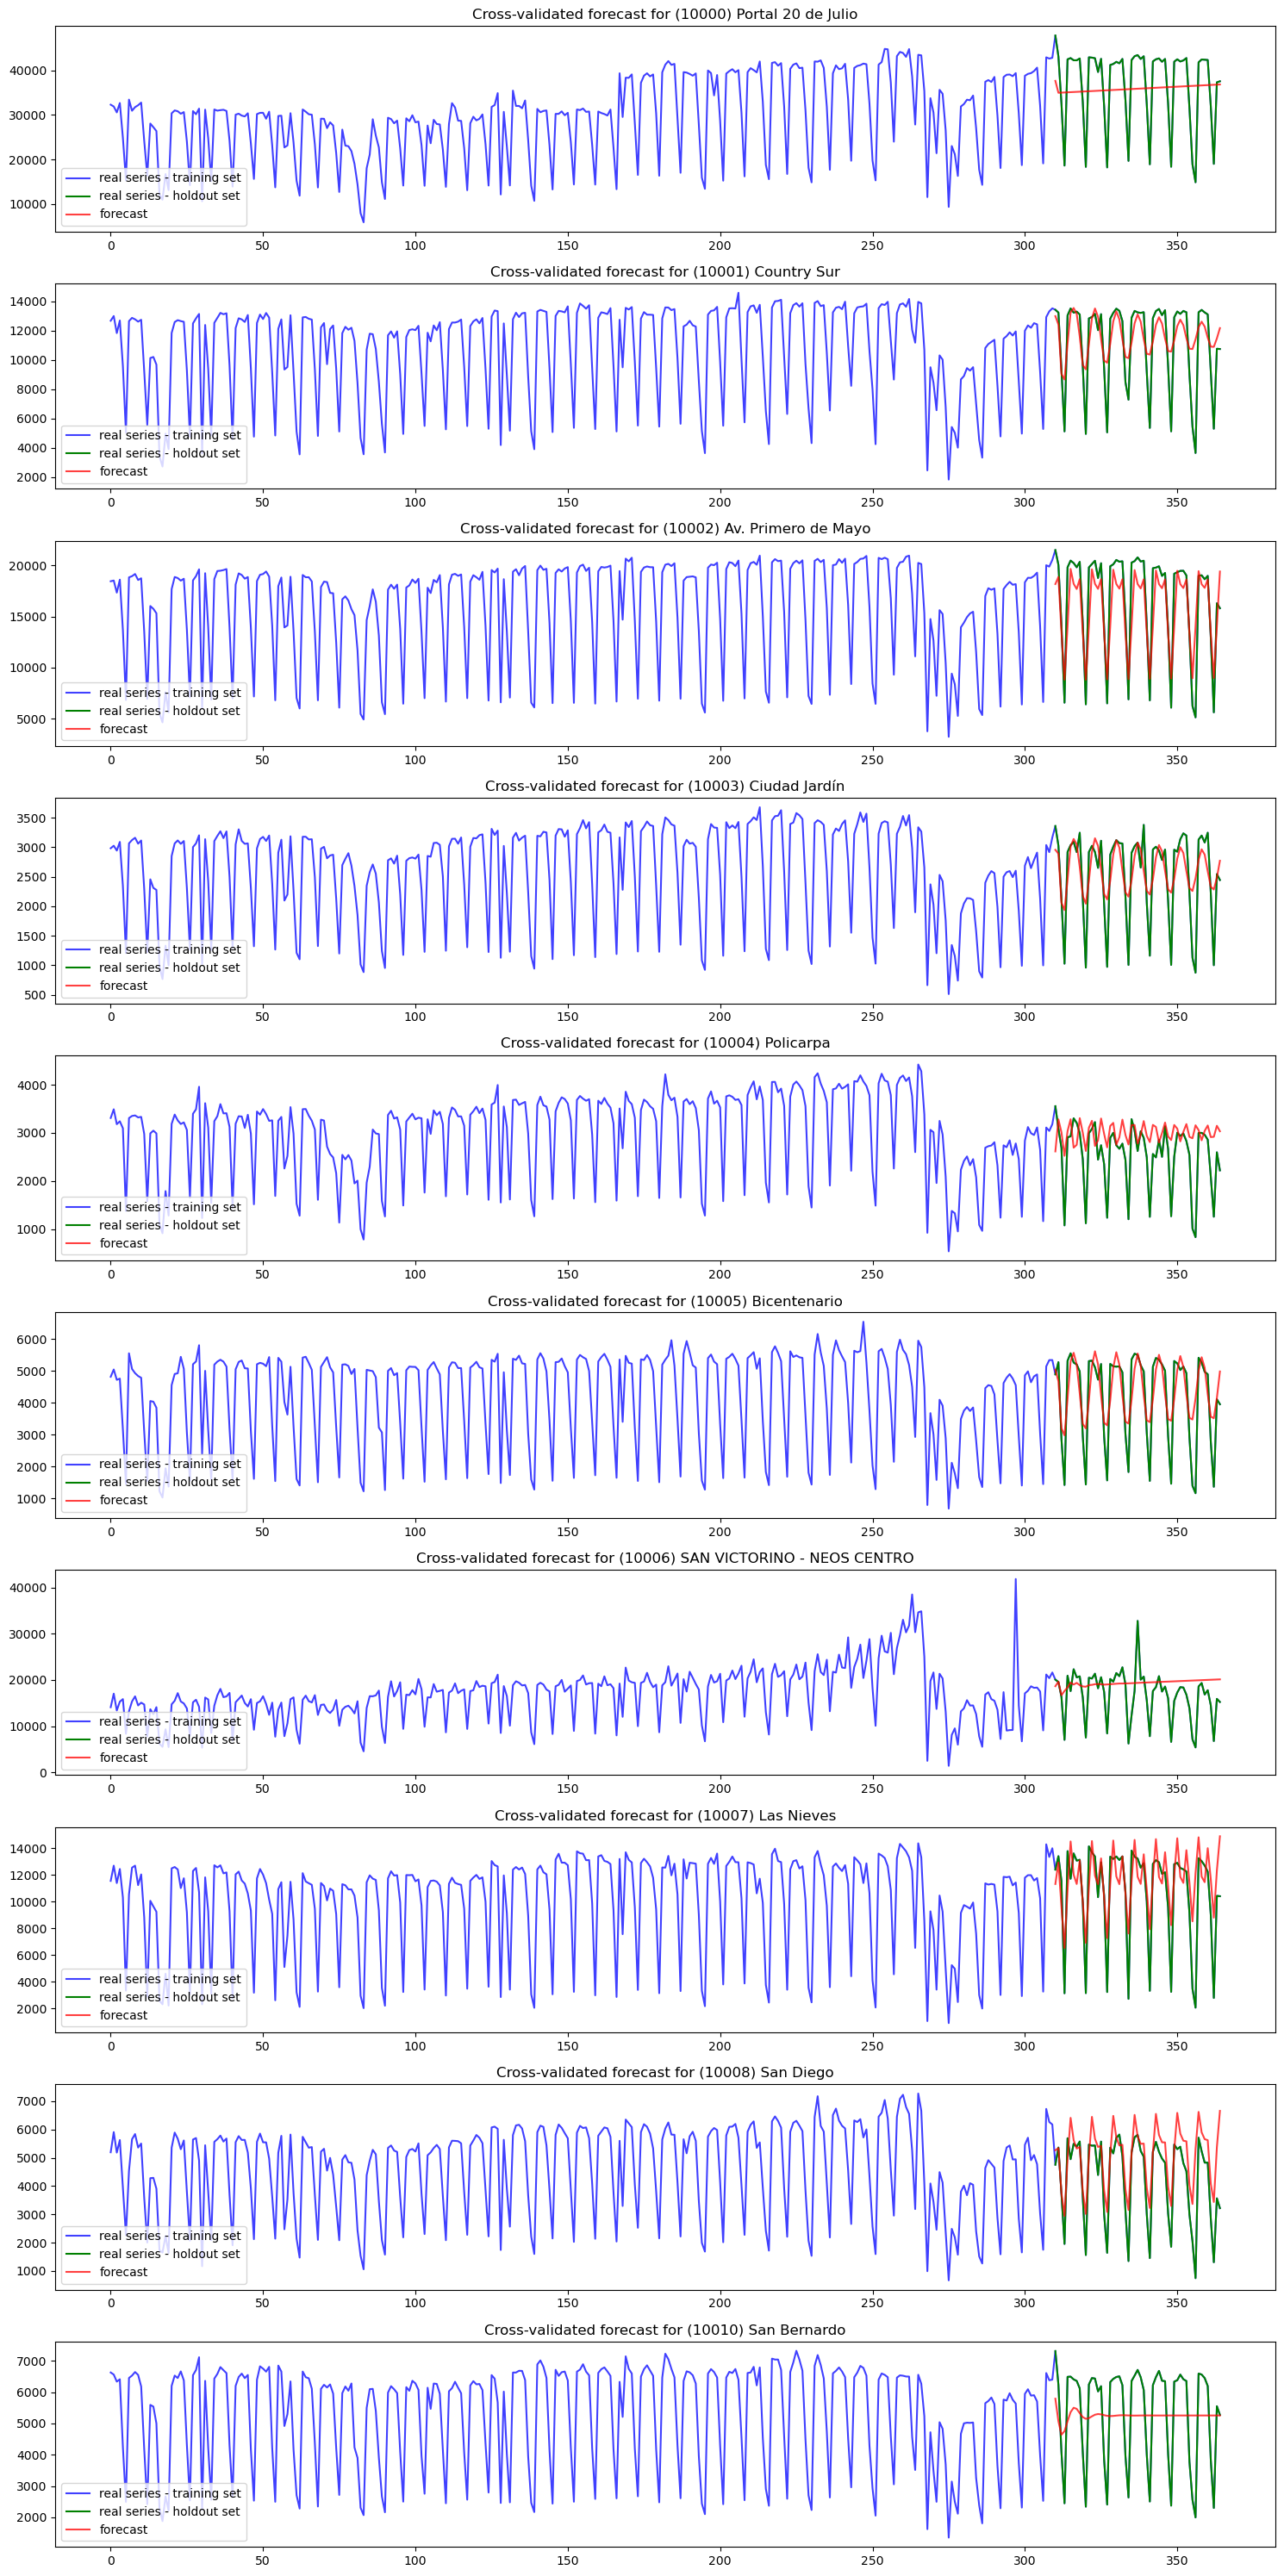

In [82]:
plot_predictions(predictions_mae, df_a, holdout_set)

In [83]:
# Plot the residuals
def plot_residuals(residuals):
    fig, axes = plt.subplots(10, 3, figsize=(15, 30))
    fig.tight_layout(pad=4.0)

    for i, (key,resids) in enumerate(residuals.items()):
        # --- Columna 1: Scatterplot ---
        axes[i, 0].scatter(range(len(resids)), resids, alpha=0.7)
        axes[i, 0].set_title(f"{key} - Residuos")
        axes[i, 0].set_xlabel("Índice temporal")
        axes[i, 0].set_ylabel("Error")

        # --- Columna 2: Histograma con curva normal ---
        sns.histplot(resids, kde=True, ax=axes[i, 1], color="skyblue", stat="density")
        mu, sigma = np.mean(resids), np.std(resids)
        x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
        axes[i, 1].plot(x, norm.pdf(x, mu, sigma), 'r', lw=0.75)
        axes[i, 1].set_title(f"{key} - Histograma residuos")

        # --- Columna 3: QQ plot ---
        sm.qqplot(resids, line='45', ax=axes[i, 2], fit=True)
        axes[i, 2].set_title(f"{key} - QQ Plot")

    plt.show()


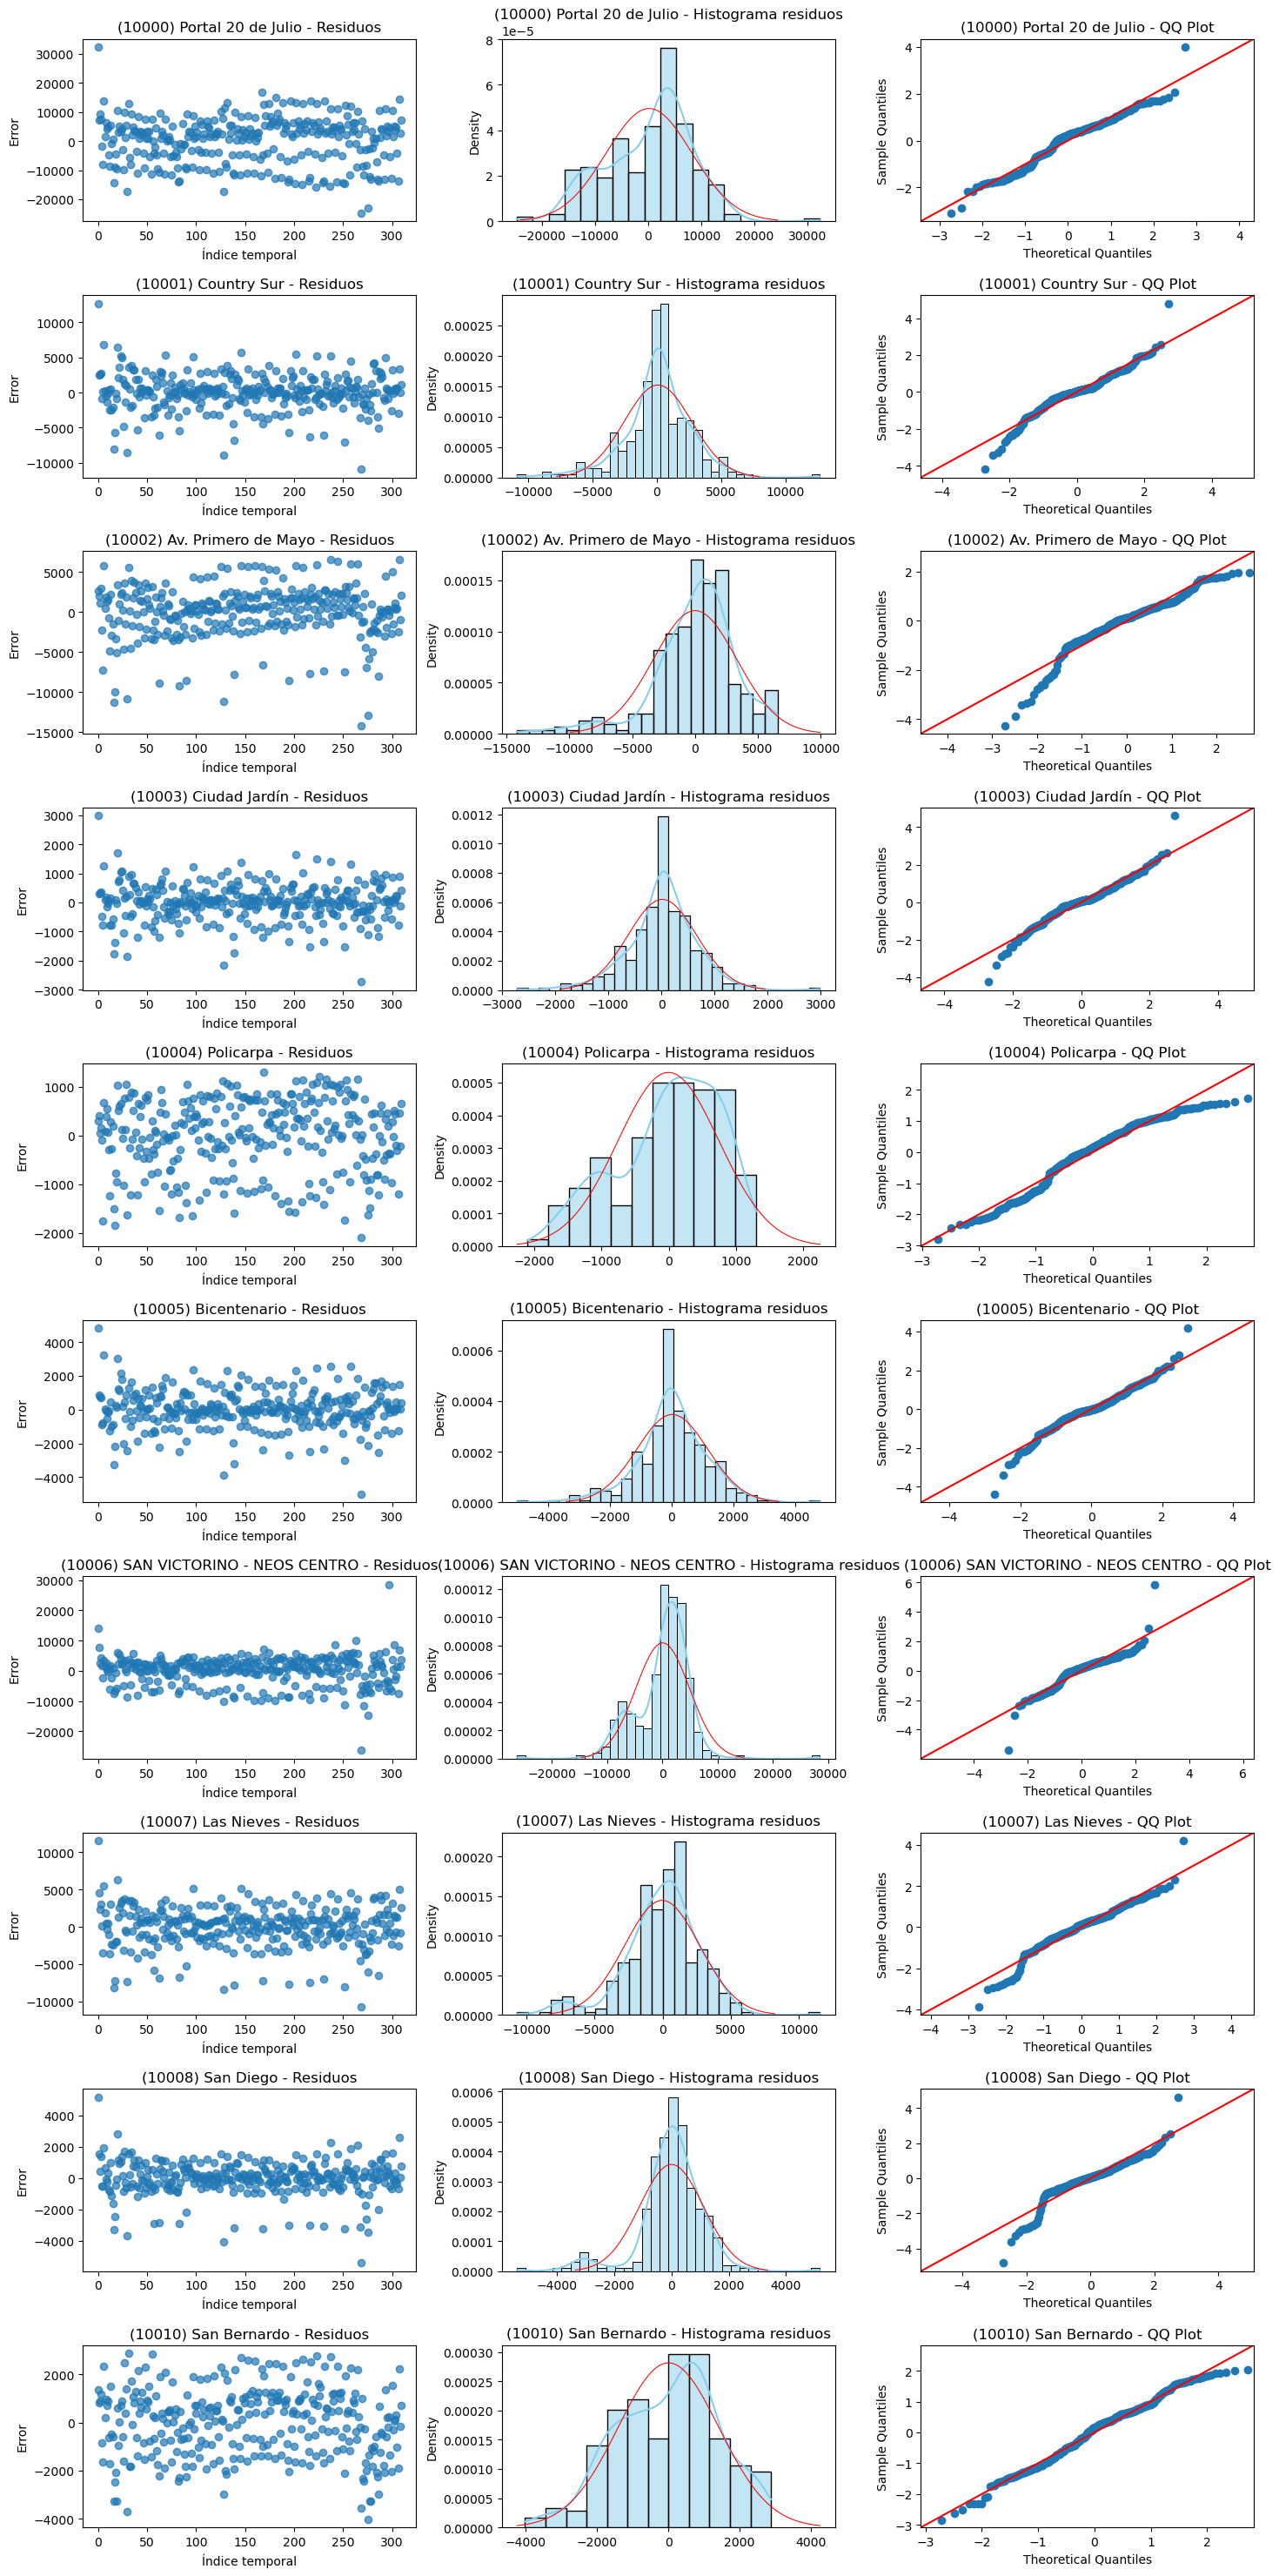

In [84]:
plot_residuals(residuals_mae)

NOTE: BEST PERFORMANCE IN PREDICTIONS IS WITH BEST_MODELS_MAE!!